# ViralLens AI — YouTube Viral Video Prediction Platform
## Notebook 1: Data Cleaning, Feature Engineering, Target Variable & EDA

**Dataset columns:** `video_id`, `title`, `publishedAt`, `channelId`, `channelTitle`, `categoryId`, `trending_date`, `tags`, `view_count`, `likes`, `comment_count`, `thumbnail_link`, `description`, `is_trending`

---

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Install & Import Libraries

In [8]:
# Install any missing libraries (Kaggle already has most)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'vaderSentiment', 'wordcloud', '--quiet'])

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset

In [9]:
# ── Kaggle path ──────────────────────────────────────────────────────────────
# Update 'your-dataset-slug' to match your Kaggle dataset name
KAGGLE_PATH = '/content/drive/MyDrive/Youtube_Videos.csv'


DATA_PATH = KAGGLE_PATH
print('Using:', DATA_PATH)

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Using: /content/drive/MyDrive/Youtube_Videos.csv
Shape: (390043, 14)


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,comment_count,thumbnail_link,description,is_trending
0,G4M_621v1As,college farewell video#trending #viralshorts,2025-04-12T02:06:42Z,UC7k_7IF3s3TY-cowwxs_yWw,Vk_07_rider,22,11/8/2025,"college farewell video, DDU farewell video, fa...",125784084,1557178,1583,https://i.ytimg.com/vi/G4M_621v1As/default.jpg,DDU farewell party video \n college farewell v...,1
1,z2voqo_Jhx4,Busking in Manchester 🇬🇧 #blindfaith #guitar #...,2025-04-06T11:35:53Z,UCM_9JHB3xXPSzJfTkD86AtA,Leonardo Patrick,10,11/8/2025,NaN,94744011,925529,5849,https://i.ytimg.com/vi/z2voqo_Jhx4/default.jpg,NaN,1
2,jHIt9oHFLsw,This is what happens when you play Star Wars i...,2025-04-06T10:07:12Z,UC4YyKY5o60Kckk-GXOnhT2g,Violin Phonix,22,11/8/2025,NaN,61945818,1067412,4124,https://i.ytimg.com/vi/jHIt9oHFLsw/default.jpg,Full video : https://www.youtube.com/watch?v=Q...,1


In [10]:
print(df.dtypes)
print('\nMissing values:\n', df.isnull().sum())

video_id          object
title             object
publishedAt       object
channelId         object
channelTitle      object
categoryId         int64
trending_date     object
tags              object
view_count         int64
likes              int64
comment_count      int64
thumbnail_link    object
description       object
is_trending        int64
dtype: object

Missing values:
 video_id               0
title                  0
publishedAt            0
channelId              0
channelTitle           0
categoryId             0
trending_date     218362
tags              120820
view_count             0
likes                  0
comment_count          0
thumbnail_link         0
description        59300
is_trending            0
dtype: int64


## 2. Data Cleaning

In [11]:
print('=== BEFORE CLEANING ===')
print(f'Total rows: {len(df):,}')
print(f'Duplicate video_ids: {df.duplicated(subset=["video_id"]).sum():,}')
print(f'Missing view_count: {df["view_count"].isnull().sum():,}')
print(f'Missing title: {df["title"].isnull().sum():,}')

=== BEFORE CLEANING ===
Total rows: 390,043
Duplicate video_ids: 202,558
Missing view_count: 0
Missing title: 0


In [12]:
# ── 2.1 Remove duplicates ────────────────────────────────────────────────────
df = df.drop_duplicates(subset=['video_id'], keep='first')
print(f'After dedup: {len(df):,}')

# ── 2.2 Drop rows missing critical fields ────────────────────────────────────
df = df.dropna(subset=['view_count', 'title'])
print(f'After dropping null view/title: {len(df):,}')

# ── 2.3 Cast numeric columns ──────────────────────────────────────────────────
for col in ['view_count', 'likes', 'comment_count', 'categoryId']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 2.4 Drop rows with non-positive view counts ───────────────────────────────
df = df[df['view_count'] > 0]
print(f'After removing zero views: {len(df):,}')

# ── 2.5 Fill missing non-critical values ──────────────────────────────────────
df['description']   = df['description'].fillna('')
df['tags']          = df['tags'].fillna('')
df['likes']         = df['likes'].fillna(0)
df['comment_count'] = df['comment_count'].fillna(0)
df['channelTitle']  = df['channelTitle'].fillna('Unknown')

# ── 2.6 Parse dates ───────────────────────────────────────────────────────────
df['publishedAt']   = pd.to_datetime(df['publishedAt'], errors='coerce', utc=True)
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce', dayfirst=True)

print(f'\nFinal cleaned shape: {df.shape}')

After dedup: 187,485
After dropping null view/title: 187,485
After removing zero views: 186,652

Final cleaned shape: (186652, 14)


In [13]:
# ── 2.7 Text normalization helper ─────────────────────────────────────────────
EMOJI_RE = re.compile('['
    u'\U0001F600-\U0001FFFF'  # emoticons
    u'\U00002702-\U000027B0'
    u'\U000024C2-\U0001F251'
    ']+', flags=re.UNICODE)

URL_RE = re.compile(r'http\S+|www\.\S+', re.IGNORECASE)

def normalize_text(text):
    """Lowercase, remove URLs, emojis, extra whitespace."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = URL_RE.sub('', text)
    text = EMOJI_RE.sub('', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['title_clean']       = df['title'].apply(normalize_text)
df['description_clean'] = df['description'].apply(normalize_text)

print('Sample cleaned title:')
print(df[['title', 'title_clean']].head(3).to_string())

Sample cleaned title:
                                                                                             title                                                                                   title_clean
0                                                     college farewell video#trending #viralshorts                                                  college farewell video#trending #viralshorts
1  Busking in Manchester 🇬🇧 #blindfaith #guitar #stevewinwood #clapton #60s #leonardo #fyp #busker  busking in manchester #blindfaith #guitar #stevewinwood #clapton #60s #leonardo #fyp #busker
2                                     This is what happens when you play Star Wars in a Cinema..😱🍿                                   this is what happens when you play star wars in a cinema..🍿


## 3. Feature Engineering

In [14]:
sia = SentimentIntensityAnalyzer()

# ── 3.1 Title features ────────────────────────────────────────────────────────
df['title_length']        = df['title_clean'].str.len()
df['title_word_count']    = df['title_clean'].str.split().str.len()
df['title_char_count']    = df['title'].str.len()          # original (with emojis)
df['title_has_question']  = df['title'].str.contains(r'\?', na=False).astype(int)
df['title_has_exclaim']   = df['title'].str.contains(r'!',  na=False).astype(int)
df['title_num_caps_words']= df['title'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1))
df['title_has_number']    = df['title_clean'].str.contains(r'\d', na=False).astype(int)
df['title_keyword_count'] = df['title_clean'].str.split().str.len()  # alias for clarity
df['title_sentiment']     = df['title_clean'].apply(
    lambda x: sia.polarity_scores(x)['compound'])

print('Title features done.')

Title features done.


In [15]:
# ── 3.2 Description features ──────────────────────────────────────────────────
df['description_length']  = df['description_clean'].str.len()
df['description_wc']      = df['description_clean'].str.split().str.len()
df['hashtag_count']       = df['description'].str.count(r'#\w+')
df['link_count']          = df['description'].str.count(r'https?://')
df['desc_has_social']     = df['description'].str.contains(
    r'instagram|twitter|facebook|tiktok', case=False, na=False).astype(int)
df['desc_emoji_count']    = df['description'].apply(
    lambda x: len(EMOJI_RE.findall(str(x))))

print('Description features done.')

Description features done.


In [16]:
# ── 3.3 Tags features ─────────────────────────────────────────────────────────
df['tag_count'] = df['tags'].apply(
    lambda x: len([t for t in str(x).split('|') if t.strip()]) if x != '[none]' else 0)

# ── 3.4 Metadata / engagement features ───────────────────────────────────────
EPS = 1e-8
df['like_ratio']    = df['likes']         / (df['view_count'] + EPS)
df['comment_ratio'] = df['comment_count'] / (df['view_count'] + EPS)
df['engagement']    = df['like_ratio'] + df['comment_ratio']  # composite score

# ── 3.5 Temporal features ─────────────────────────────────────────────────────
df['publish_hour']    = df['publishedAt'].dt.hour
df['publish_dow']     = df['publishedAt'].dt.dayofweek          # 0=Mon
df['publish_dow_name']= df['publishedAt'].dt.day_name()
df['publish_month']   = df['publishedAt'].dt.month
df['publish_year']    = df['publishedAt'].dt.year
df['is_weekend']      = (df['publish_dow'] >= 5).astype(int)

# Days to reach trending
df['days_to_trend']   = (df['trending_date'] - df['publishedAt'].dt.tz_localize(None)).dt.days
df['days_to_trend']   = df['days_to_trend'].clip(lower=0)

# ── 3.6 Category mapping ──────────────────────────────────────────────────────
CAT_MAP = {
    1:'Film & Animation', 2:'Autos & Vehicles', 10:'Music', 15:'Pets & Animals',
    17:'Sports', 18:'Short Movies', 19:'Travel & Events', 20:'Gaming',
    21:'Videoblogging', 22:'People & Blogs', 23:'Comedy', 24:'Entertainment',
    25:'News & Politics', 26:'Howto & Style', 27:'Education',
    28:'Science & Technology', 29:'Nonprofits & Activism'
}
df['category_name'] = df['categoryId'].map(CAT_MAP).fillna('Unknown')

print('All metadata and temporal features done.')
print(f'Total features: {df.shape[1]}')

All metadata and temporal features done.
Total features: 43


In [17]:
# Quick peek at new features
feat_cols = [
    'title_length','title_keyword_count','title_sentiment','title_has_question',
    'title_has_exclaim','description_length','hashtag_count','link_count',
    'tag_count','like_ratio','comment_ratio','engagement','publish_hour',
    'publish_dow','is_weekend','category_name'
]
df[feat_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
title_length,186652.0,60.746,24.493,0.000,41.000,59.000,82.000,130.000
title_keyword_count,186652.0,9.717,3.993,0.000,7.000,9.000,12.000,29.000
title_sentiment,186652.0,0.090,0.327,-0.977,0.000,0.000,0.296,0.991
title_has_question,186652.0,0.072,0.259,0.000,0.000,0.000,0.000,1.000
title_has_exclaim,186652.0,0.136,0.342,0.000,0.000,0.000,0.000,1.000
description_length,186652.0,183.127,397.862,0.000,30.000,109.000,129.000,4987.000
hashtag_count,186652.0,1.051,4.114,0.000,0.000,0.000,0.000,426.000
link_count,186652.0,1.350,4.085,0.000,0.000,0.000,1.000,90.000
tag_count,186652.0,2.890,7.363,0.000,0.000,1.000,1.000,78.000
like_ratio,186652.0,0.048,3.797,0.000,0.012,0.027,0.048,1586.000


## 4. Define Target Variable — `is_viral`

In [18]:
# Strategy: top-10% by view_count within the cleaned dataset
VIRAL_QUANTILE = 0.90
threshold = df['view_count'].quantile(VIRAL_QUANTILE)
df['is_viral'] = (df['view_count'] >= threshold).astype(int)

print(f'Viral threshold (90th pct): {threshold:,.0f} views')
print('\nClass distribution:')
print(df['is_viral'].value_counts().rename({0:'Non-Viral', 1:'Viral'}))
print('\nClass ratio:')
print(df['is_viral'].value_counts(normalize=True).rename({0:'Non-Viral', 1:'Viral'}).round(3))

Viral threshold (90th pct): 12,767,409 views

Class distribution:
is_viral
Non-Viral    167986
Viral         18666
Name: count, dtype: int64

Class ratio:
is_viral
Non-Viral    0.9
Viral        0.1
Name: proportion, dtype: float64


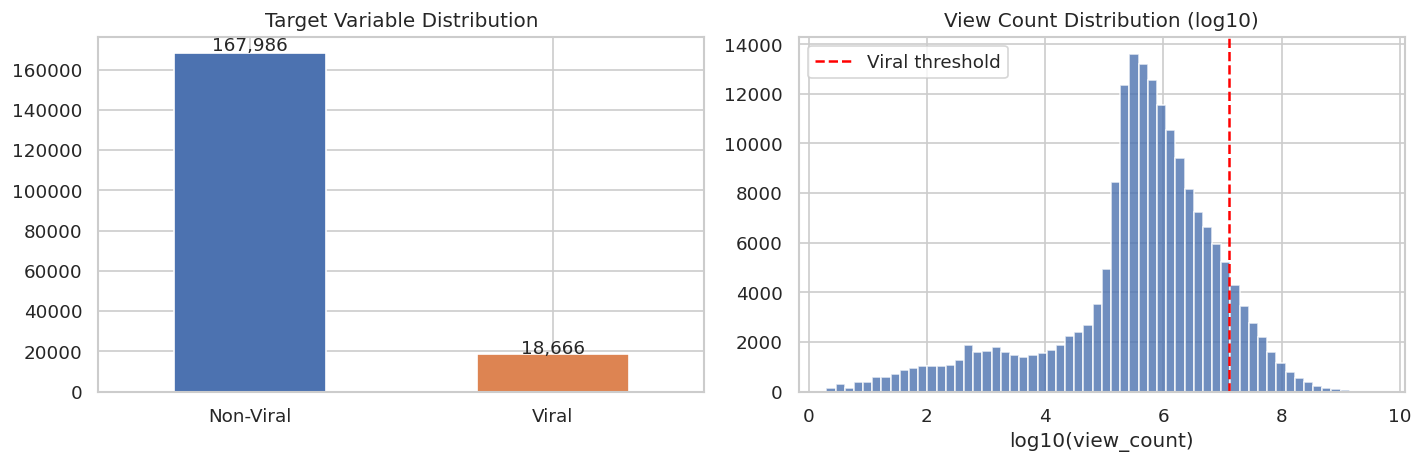

In [19]:
# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
vc = df['is_viral'].value_counts().rename({0:'Non-Viral', 1:'Viral'})
vc.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
axes[0].set_title('Target Variable Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x()+0.25, p.get_height()*1.01), ha='center')

# View count distribution
axes[1].hist(np.log10(df['view_count']+1), bins=60, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[1].axvline(np.log10(threshold+1), color='red', linestyle='--', label=f'Viral threshold')
axes[1].set_title('View Count Distribution (log10)')
axes[1].set_xlabel('log10(view_count)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis (EDA)

### 5.1 — What Titles Perform Best?

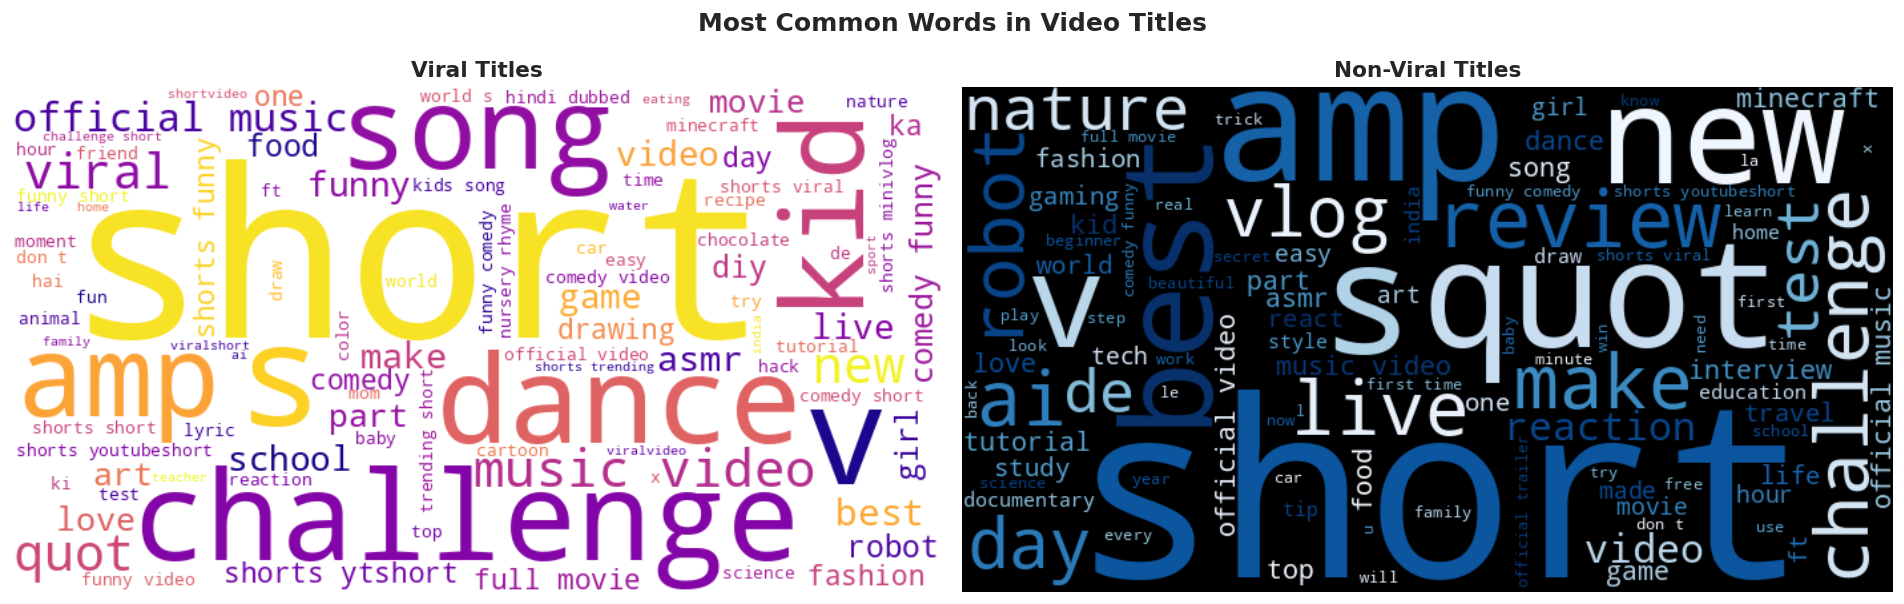

In [20]:
# Word cloud — viral vs non-viral titles
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, label, color, name in zip(
        axes, [1, 0],
        ['white', 'black'],
        ['Viral Titles', 'Non-Viral Titles']):
    corpus = ' '.join(df[df['is_viral'] == label]['title_clean'].dropna())
    wc = WordCloud(width=700, height=380, background_color=color,
                   max_words=100, colormap='plasma' if label==1 else 'Blues').generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(name, fontsize=13, fontweight='bold')
plt.suptitle('Most Common Words in Video Titles', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

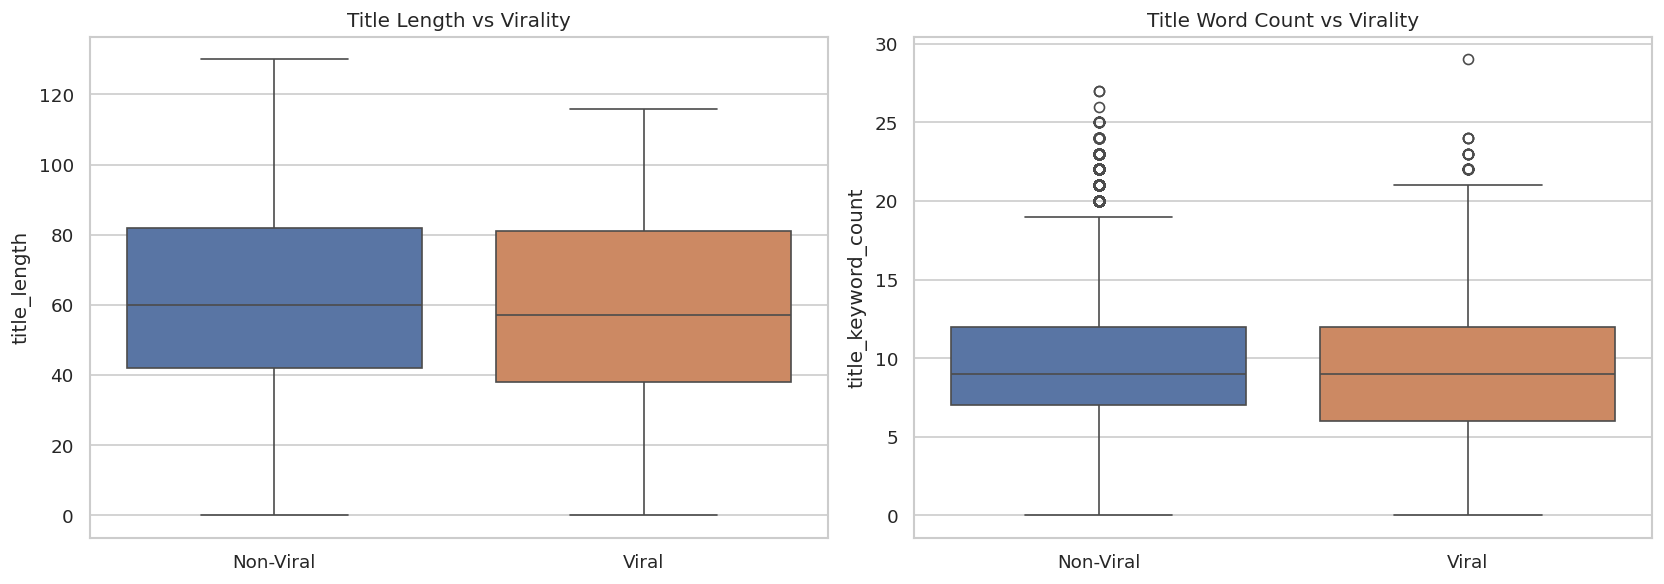

In [21]:
# Title length vs virality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(ax=axes[0], x='is_viral', y='title_length', data=df,
            palette={'0':'#4C72B0', '1':'#DD8452'})
axes[0].set_xticklabels(['Non-Viral', 'Viral'])
axes[0].set_title('Title Length vs Virality')
axes[0].set_xlabel('')

sns.boxplot(ax=axes[1], x='is_viral', y='title_keyword_count', data=df,
            palette={'0':'#4C72B0', '1':'#DD8452'})
axes[1].set_xticklabels(['Non-Viral', 'Viral'])
axes[1].set_title('Title Word Count vs Virality')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

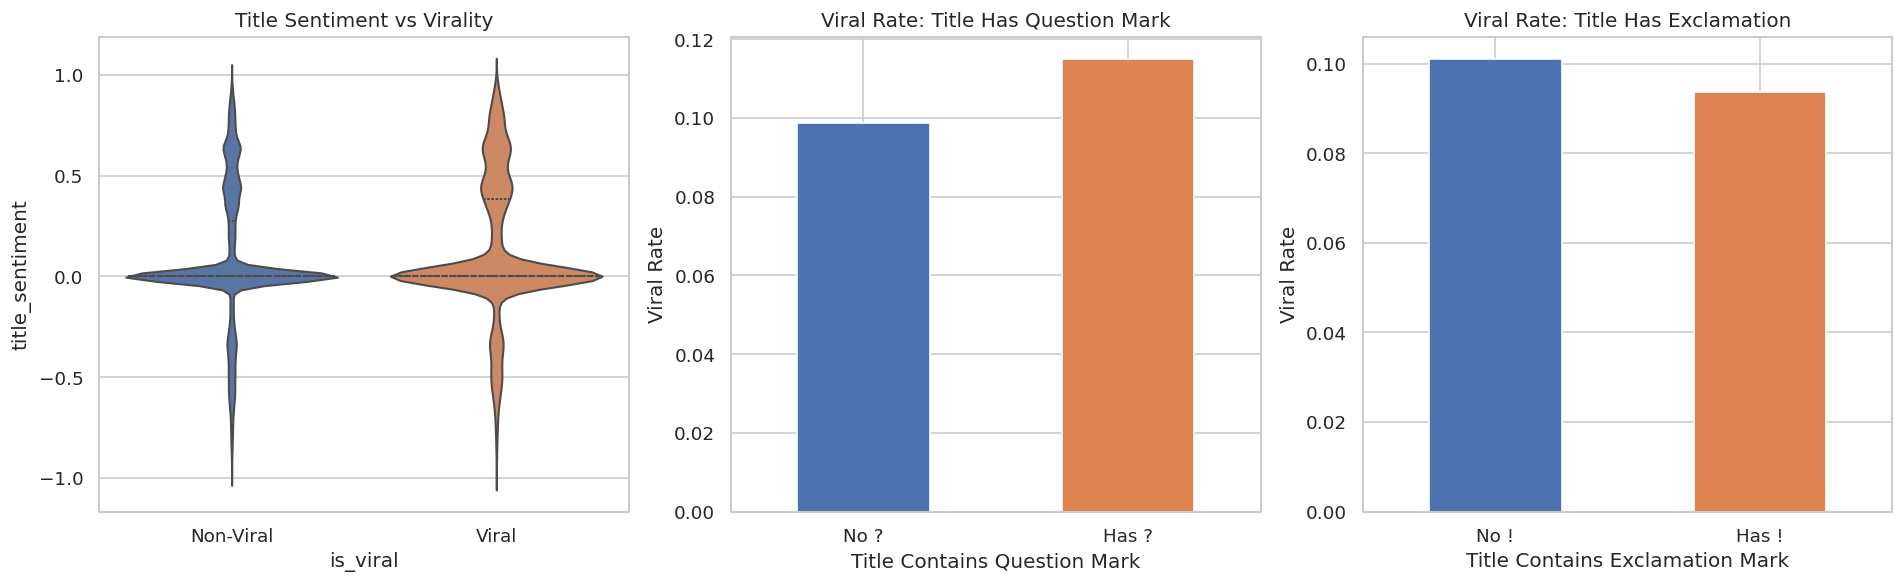

In [22]:
# Sentiment, questions, exclamation marks
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.violinplot(ax=axes[0], x='is_viral', y='title_sentiment', data=df,
               palette={'0':'#4C72B0', '1':'#DD8452'}, inner='quartile')
axes[0].set_xticklabels(['Non-Viral', 'Viral'])
axes[0].set_title('Title Sentiment vs Virality')

# Viral rate for ?-questions
q_rate = df.groupby('title_has_question')['is_viral'].mean().rename({0:'No ?', 1:'Has ?'})
q_rate.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
axes[1].set_title('Viral Rate: Title Has Question Mark')
axes[1].set_ylabel('Viral Rate')
axes[1].set_xlabel('Title Contains Question Mark')
axes[1].tick_params(axis='x', rotation=0)

e_rate = df.groupby('title_has_exclaim')['is_viral'].mean().rename({0:'No !', 1:'Has !'})
e_rate.plot(kind='bar', ax=axes[2], color=['#4C72B0','#DD8452'], edgecolor='white', width=0.5)
axes[2].set_title('Viral Rate: Title Has Exclamation')
axes[2].set_ylabel('Viral Rate')
axes[2].set_xlabel('Title Contains Exclamation Mark')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 5.2 — Does Upload Time Matter?

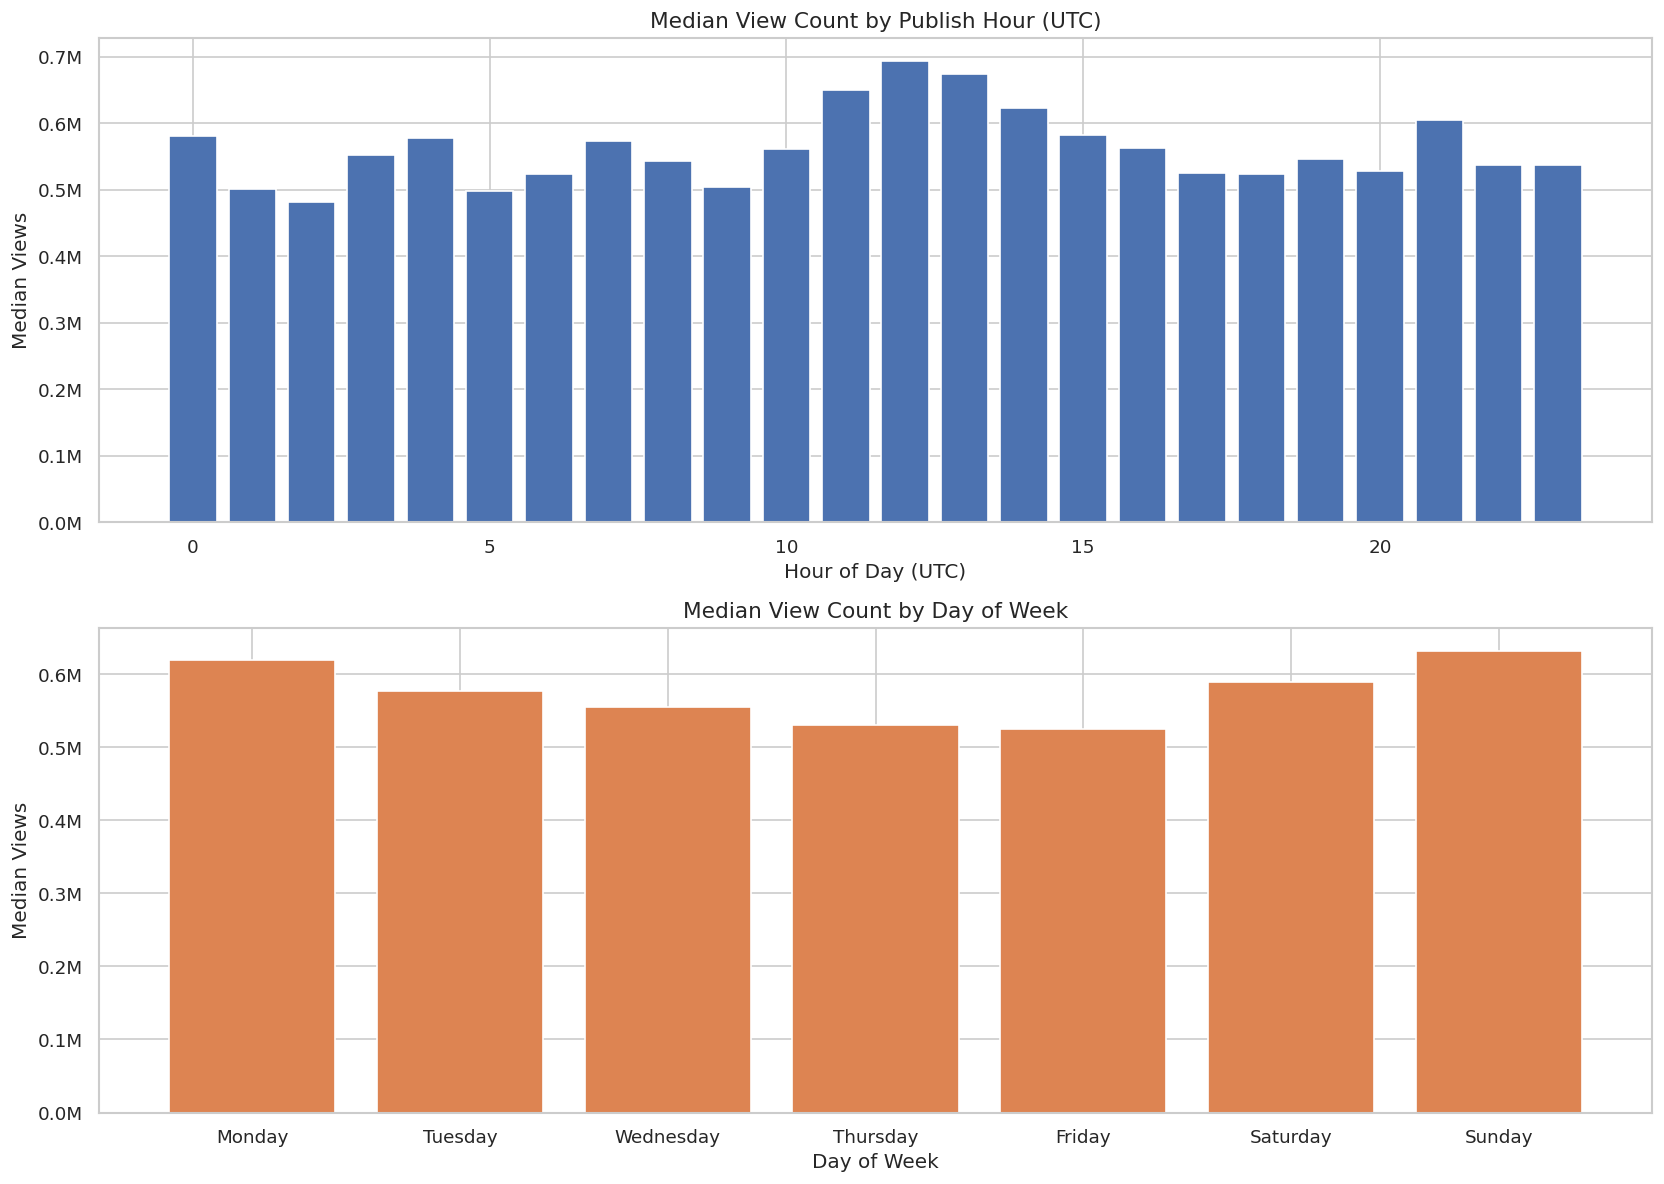

In [23]:
# Avg views by hour of day and day of week
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

hour_views = df.groupby('publish_hour')['view_count'].median()
axes[0].bar(hour_views.index, hour_views.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Median View Count by Publish Hour (UTC)', fontsize=13)
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Median Views')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_views = df.groupby('publish_dow_name')['view_count'].median().reindex(DOW_ORDER)
axes[1].bar(dow_views.index, dow_views.values, color='#DD8452', edgecolor='white')
axes[1].set_title('Median View Count by Day of Week', fontsize=13)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Median Views')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

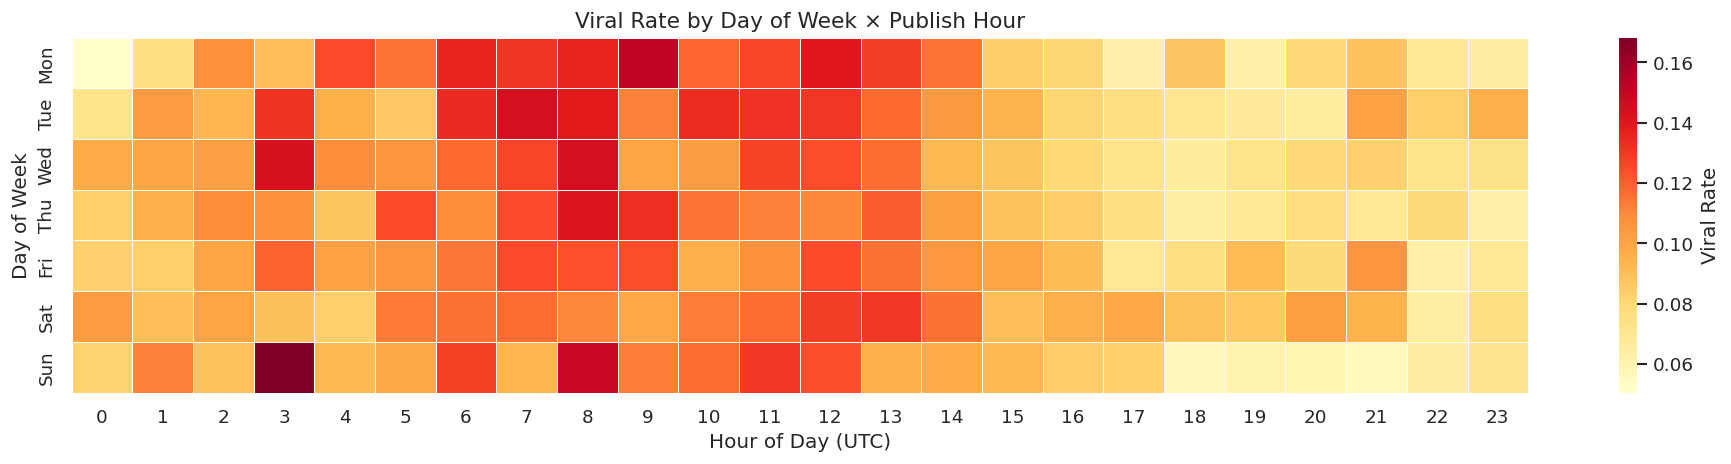

In [24]:
# Viral rate heatmap: hour x dow
pivot = df.groupby(['publish_dow', 'publish_hour'])['is_viral'].mean().unstack(level=1)
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][:len(pivot)]

plt.figure(figsize=(16, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label':'Viral Rate'})
plt.title('Viral Rate by Day of Week × Publish Hour', fontsize=13)
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

### 5.3 — Do Hashtags Increase Views?

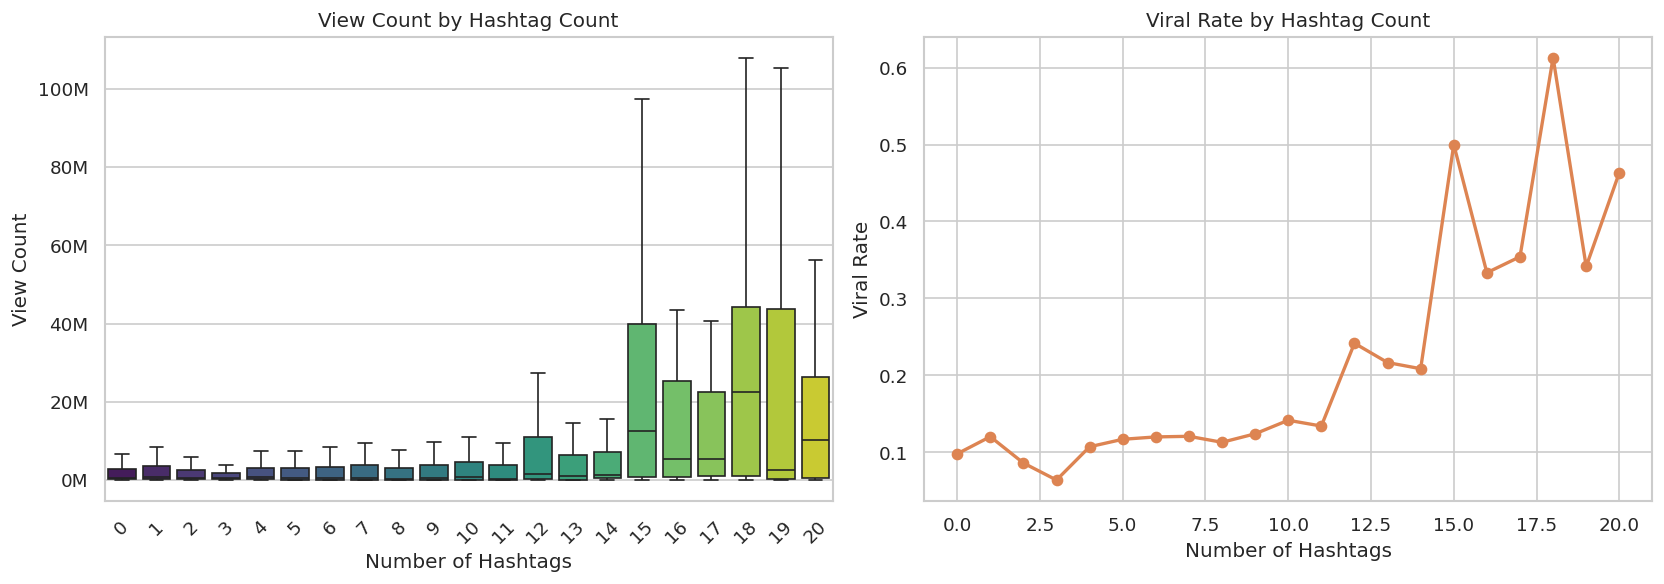

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap hashtag_count for readability
hdf = df[df['hashtag_count'] <= 20].copy()

sns.boxplot(ax=axes[0], x='hashtag_count', y='view_count', data=hdf,
            order=range(21), palette='viridis', showfliers=False)
axes[0].set_title('View Count by Hashtag Count')
axes[0].set_xlabel('Number of Hashtags')
axes[0].set_ylabel('View Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))
axes[0].tick_params(axis='x', rotation=45)

viral_rate_hashtag = df.groupby('hashtag_count')['is_viral'].mean().reset_index()
viral_rate_hashtag = viral_rate_hashtag[viral_rate_hashtag['hashtag_count'] <= 20]
axes[1].plot(viral_rate_hashtag['hashtag_count'], viral_rate_hashtag['is_viral'],
             marker='o', color='#DD8452', linewidth=2)
axes[1].set_title('Viral Rate by Hashtag Count')
axes[1].set_xlabel('Number of Hashtags')
axes[1].set_ylabel('Viral Rate')

plt.tight_layout()
plt.show()

### 5.4 — Category Analysis

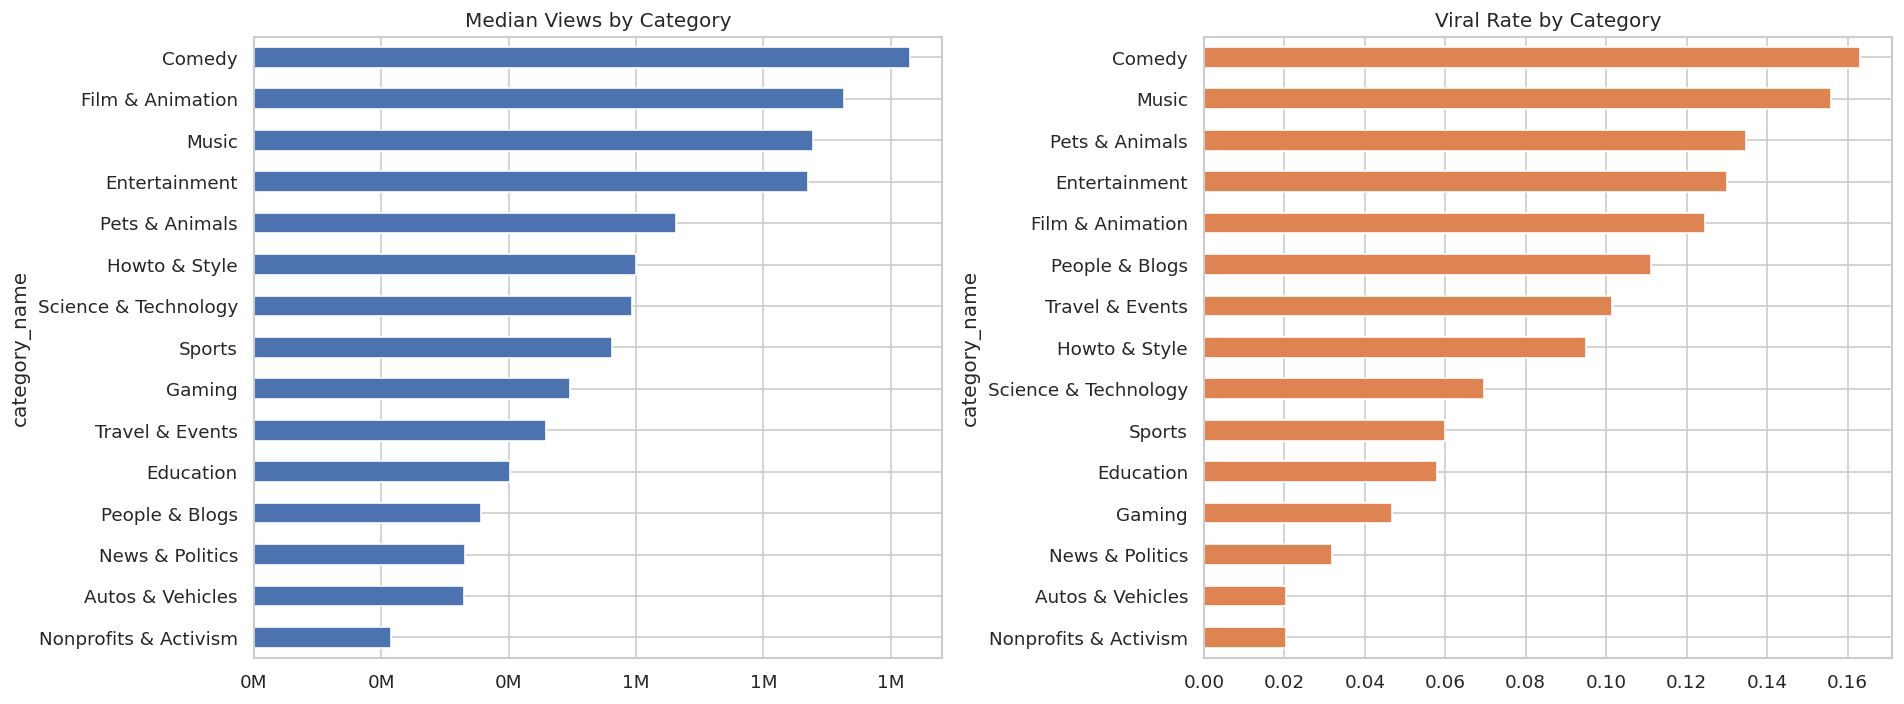

In [26]:
cat_stats = df.groupby('category_name').agg(
    video_count=('video_id','count'),
    median_views=('view_count','median'),
    viral_rate=('is_viral','mean')
).sort_values('median_views', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_stats['median_views'].plot(kind='barh', ax=axes[0], color='#4C72B0', edgecolor='white')
axes[0].set_title('Median Views by Category')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M'))

cat_stats['viral_rate'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[1], color='#DD8452', edgecolor='white')
axes[1].set_title('Viral Rate by Category')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 5.5 — Engagement Features vs Virality

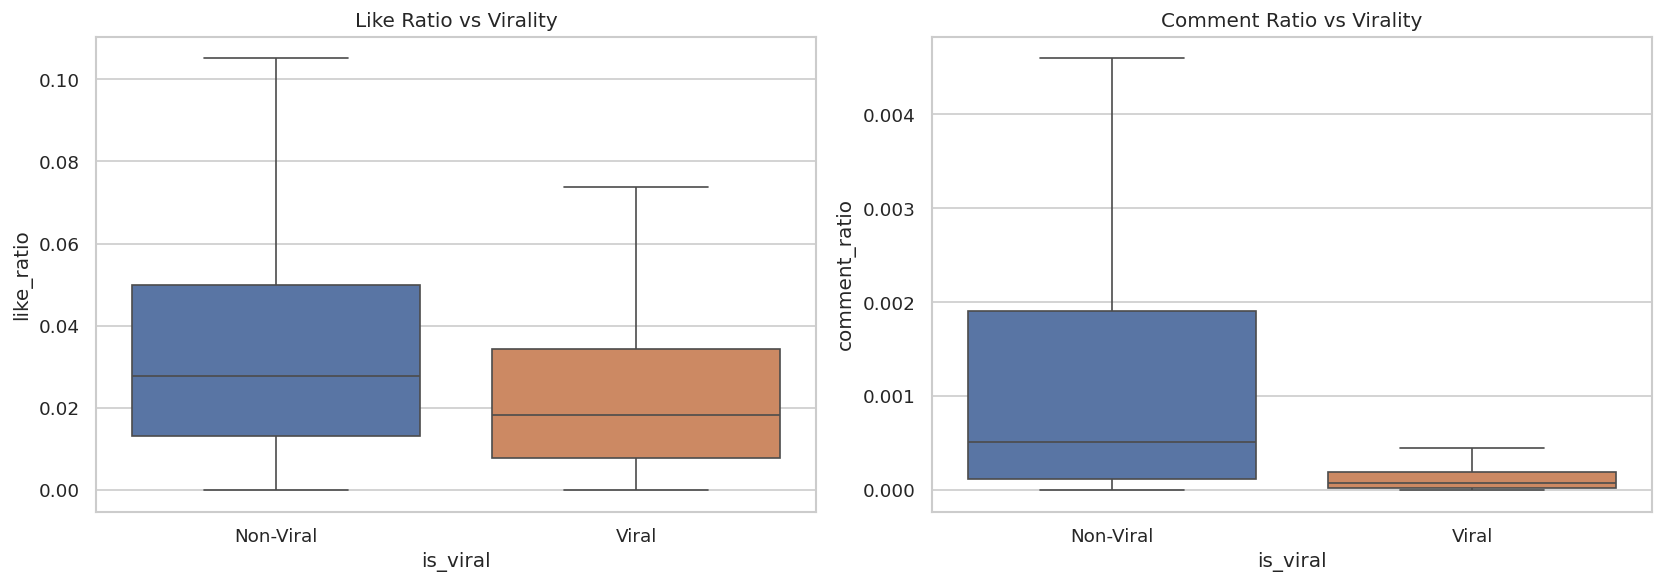

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Like ratio
sns.boxplot(ax=axes[0], x='is_viral', y='like_ratio', data=df,
            palette={"0":'#4C72B0', "1":'#DD8452'}, showfliers=False)
axes[0].set_xticklabels(['Non-Viral', 'Viral'])
axes[0].set_title('Like Ratio vs Virality')

# Comment ratio
sns.boxplot(ax=axes[1], x='is_viral', y='comment_ratio', data=df,
            palette={"0":'#4C72B0', "1":'#DD8452'}, showfliers=False)
axes[1].set_xticklabels(['Non-Viral', 'Viral'])
axes[1].set_title('Comment Ratio vs Virality')

plt.tight_layout()
plt.show()

### 5.6 — Feature Correlation Heatmap

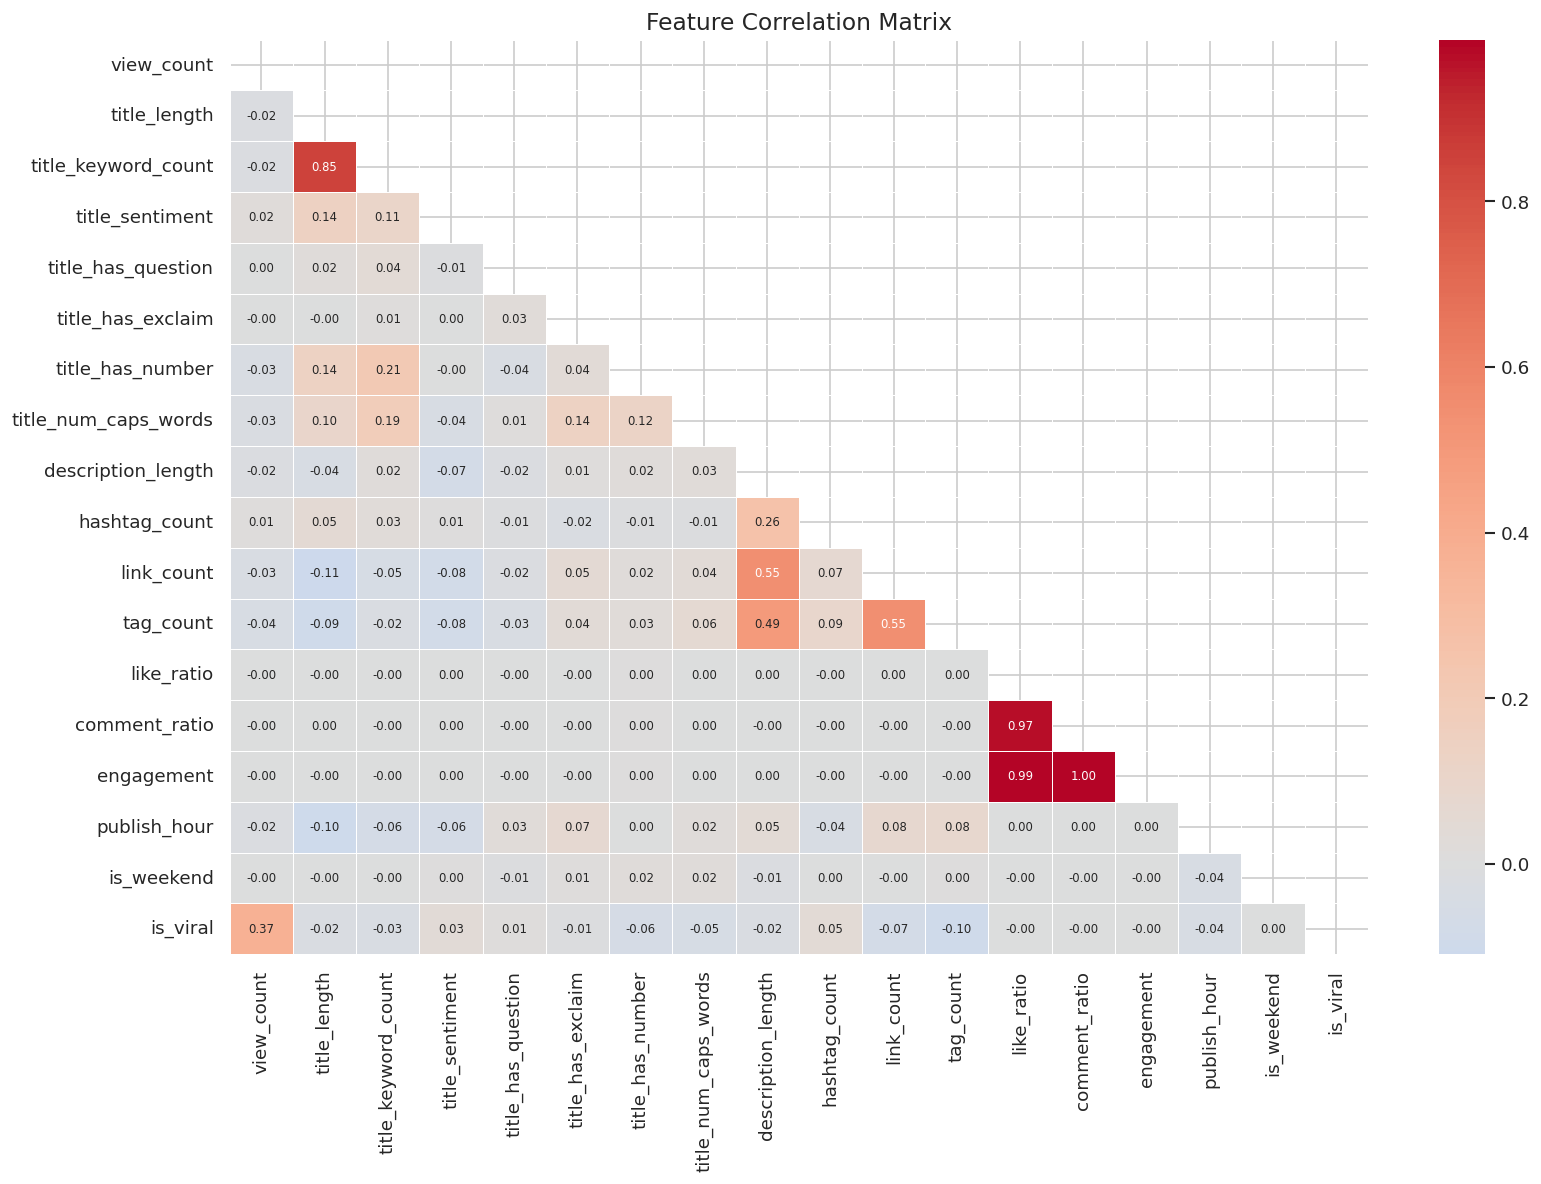

In [28]:
CORR_COLS = [
    'view_count','title_length','title_keyword_count','title_sentiment',
    'title_has_question','title_has_exclaim','title_has_number','title_num_caps_words',
    'description_length','hashtag_count','link_count','tag_count',
    'like_ratio','comment_ratio','engagement','publish_hour','is_weekend','is_viral'
]

corr = df[CORR_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### 5.7 — Top Channels by Viral Videos

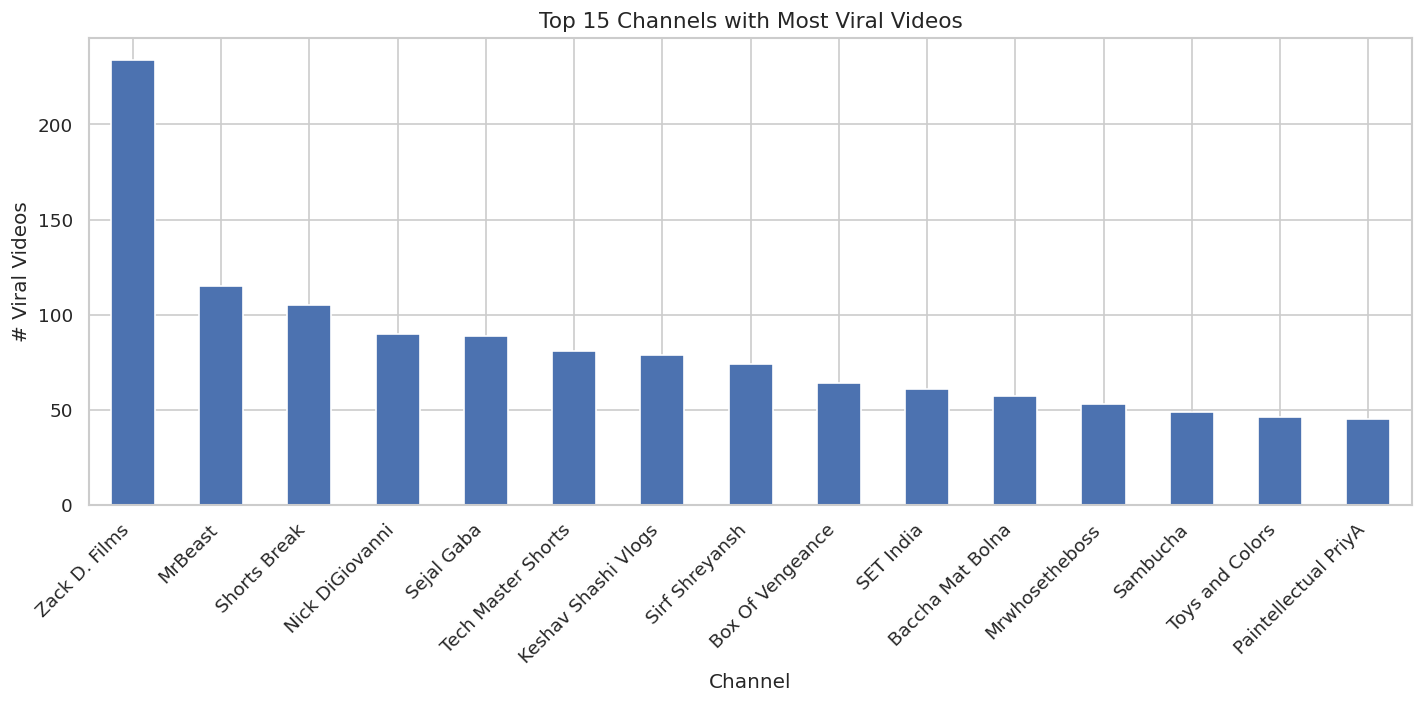

In [29]:
top_channels = (
    df[df['is_viral'] == 1]
    .groupby('channelTitle')['video_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
top_channels.plot(kind='bar', color='#4C72B0', edgecolor='white')
plt.title('Top 15 Channels with Most Viral Videos', fontsize=13)
plt.xlabel('Channel')
plt.ylabel('# Viral Videos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.8 — Tags Analysis

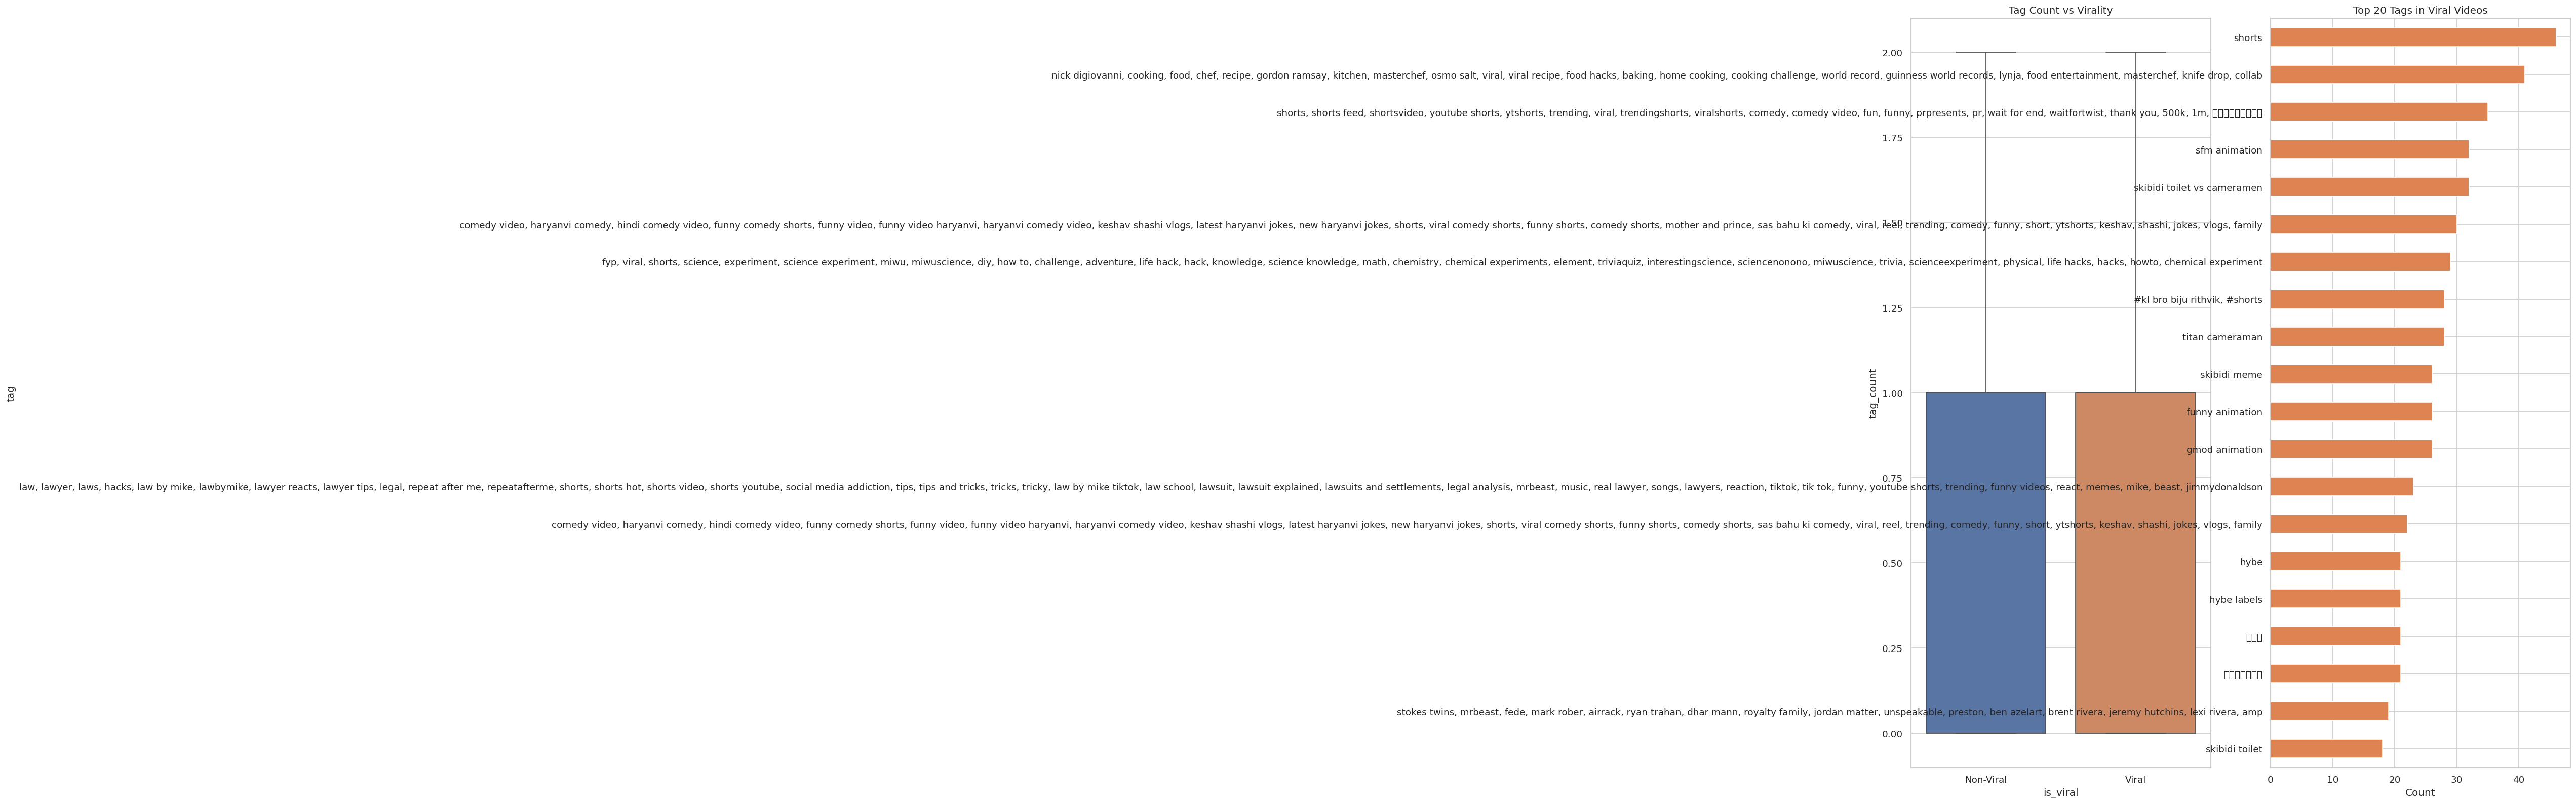

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 16))

sns.boxplot(ax=axes[0], x='is_viral', y='tag_count', data=df,
            palette={"0":'#4C72B0', "1":'#DD8452'}, showfliers=False)
axes[0].set_xticklabels(['Non-Viral', 'Viral'])
axes[0].set_title('Tag Count vs Virality')

# Most common tags in viral videos
viral_tags = df[df['is_viral']==1]['tags'].dropna()
all_tags = [t.strip().lower() for row in viral_tags
            for t in str(row).split('|') if t.strip() and t.strip() != '[none]']
tag_freq = Counter(all_tags).most_common(20)
tag_df = pd.DataFrame(tag_freq, columns=['tag','count'])
tag_df.set_index('tag')['count'].plot(kind='barh', ax=axes[1],
                                       color='#DD8452', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 20 Tags in Viral Videos')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

### 5.9 — View Count Trend Over Time

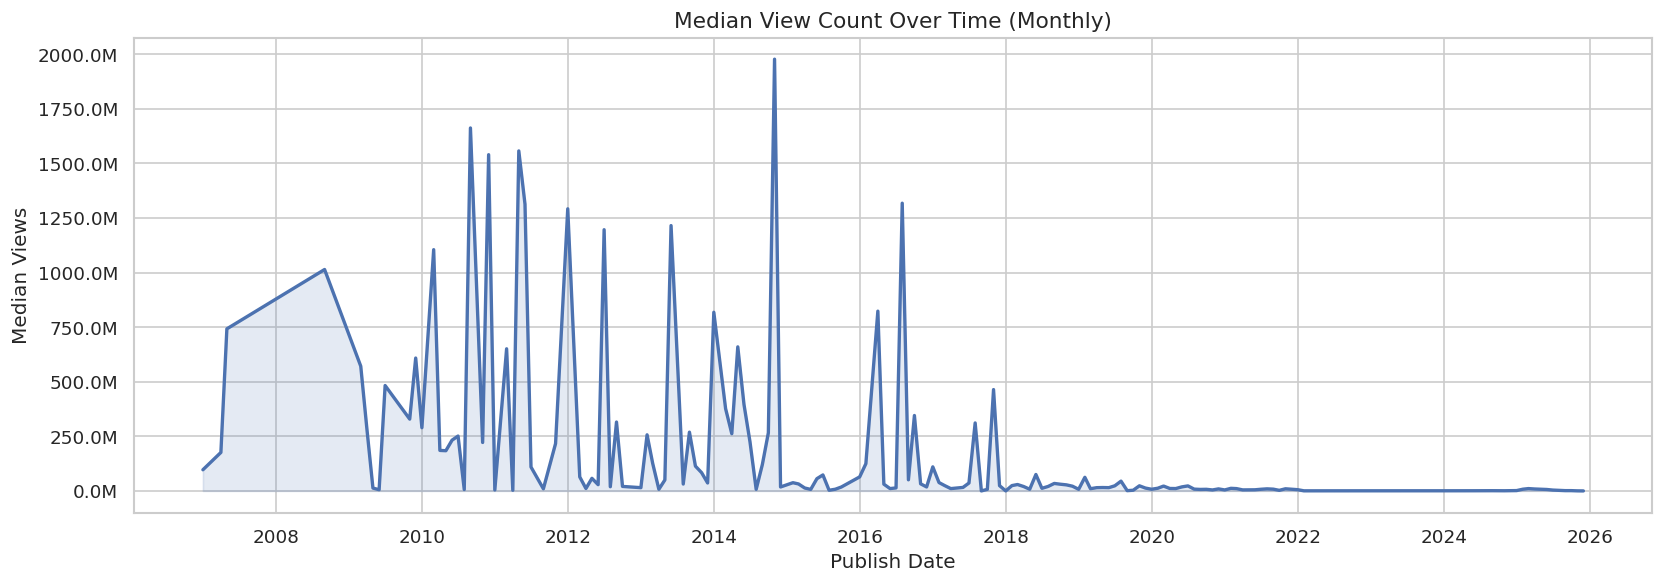

In [31]:
time_trend = (
    df.set_index('publishedAt')
    .resample('ME')['view_count']
    .median()
    .dropna()
)

plt.figure(figsize=(14, 5))
plt.plot(time_trend.index, time_trend.values, color='#4C72B0', linewidth=2)
plt.fill_between(time_trend.index, time_trend.values, alpha=0.15, color='#4C72B0')
plt.title('Median View Count Over Time (Monthly)', fontsize=13)
plt.xlabel('Publish Date')
plt.ylabel('Median Views')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

## 6. Save Cleaned Dataset

In [32]:
OUTPUT_PATH = '/content/drive/MyDrive/Clean Dataset.csv'

# Drop raw redundant columns before saving
KEEP_COLS = [
    'video_id','title','title_clean','description_clean',
    'channelId','channelTitle','category_name','categoryId',
    'publishedAt','publish_hour','publish_dow','publish_dow_name','publish_month','publish_year','is_weekend',
    'trending_date','days_to_trend','is_trending',
    'view_count','likes','comment_count',
    'like_ratio','comment_ratio','engagement',
    'title_length','title_word_count','title_char_count',
    'title_has_question','title_has_exclaim','title_has_number','title_num_caps_words','title_keyword_count','title_sentiment',
    'description_length','description_wc','hashtag_count','link_count','desc_has_social','desc_emoji_count',
    'tag_count',
    'is_viral'
]
KEEP_COLS = [c for c in KEEP_COLS if c in df.columns]
df_out = df[KEEP_COLS].copy()

df_out.to_csv(OUTPUT_PATH, index=False)
print(f'Saved cleaned dataset → {OUTPUT_PATH}')
print(f'Shape: {df_out.shape}')
df_out.head(3)

Saved cleaned dataset → /content/drive/MyDrive/Clean Dataset.csv
Shape: (186652, 41)


,video_id,title,title_clean,description_clean,channelId,channelTitle,category_name,categoryId,publishedAt,publish_hour,...,title_keyword_count,title_sentiment,description_length,description_wc,hashtag_count,link_count,desc_has_social,desc_emoji_count,tag_count,is_viral
0,G4M_621v1As,college farewell video#trending #viralshorts,college farewell video#trending #viralshorts,ddu farewell party video college farewell vide...,UC7k_7IF3s3TY-cowwxs_yWw,Vk_07_rider,People & Blogs,22,2025-04-12 02:06:42+00:00,2,...,4,0.000,100,13,3,0,0,0,1,1
1,z2voqo_Jhx4,Busking in Manchester 🇬🇧 #blindfaith #guitar #...,busking in manchester #blindfaith #guitar #ste...,,UCM_9JHB3xXPSzJfTkD86AtA,Leonardo Patrick,Music,10,2025-04-06 11:35:53+00:00,11,...,11,0.000,0,0,0,0,0,0,0,1
2,jHIt9oHFLsw,This is what happens when you play Star Wars i...,this is what happens when you play star wars i...,full video :,UC4YyKY5o60Kckk-GXOnhT2g,Violin Phonix,People & Blogs,22,2025-04-06 10:07:12+00:00,10,...,12,-0.296,12,3,0,1,0,0,0,1


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
OUTPUT_PATH = '/content/drive/MyDrive/Clean Dataset.csv'
df_cleaned = pd.read_csv(OUTPUT_PATH)

print(f'Loaded cleaned dataset with shape: {df_cleaned.shape}')
display(df_cleaned.head())

Loaded cleaned dataset with shape: (186652, 41)


,video_id,title,title_clean,description_clean,channelId,channelTitle,category_name,categoryId,publishedAt,publish_hour,...,title_keyword_count,title_sentiment,description_length,description_wc,hashtag_count,link_count,desc_has_social,desc_emoji_count,tag_count,is_viral
0,G4M_621v1As,college farewell video#trending #viralshorts,college farewell video#trending #viralshorts,ddu farewell party video college farewell vide...,UC7k_7IF3s3TY-cowwxs_yWw,Vk_07_rider,People & Blogs,22,2025-04-12 02:06:42+00:00,2,...,4,0.0000,100,13,3,0,0,0,1,1
1,z2voqo_Jhx4,Busking in Manchester 🇬🇧 #blindfaith #guitar #...,busking in manchester #blindfaith #guitar #ste...,NaN,UCM_9JHB3xXPSzJfTkD86AtA,Leonardo Patrick,Music,10,2025-04-06 11:35:53+00:00,11,...,11,0.0000,0,0,0,0,0,0,0,1
2,jHIt9oHFLsw,This is what happens when you play Star Wars i...,this is what happens when you play star wars i...,full video :,UC4YyKY5o60Kckk-GXOnhT2g,Violin Phonix,People & Blogs,22,2025-04-06 10:07:12+00:00,10,...,12,-0.2960,12,3,0,1,0,0,0,1
3,gwRqLbWqKlM,LISA - FUTW (YouTube Music Nights Special Stag...,lisa - futw (youtube music nights special stag...,"lisa’s debut album, ‘alter ego’ is out now. li...",UC6-BgjsBa5R3PZQ_kZ8hKPg,LLOUD Official,Music,10,2025-03-19 03:29:33+00:00,3,...,9,0.4019,4504,790,3,9,1,0,1,1
4,prpRoyrutcE,Uljhi hai yeh kis jaal me tu…. Bengaluru ❤️,uljhi hai yeh kis jaal me tu…. bengaluru,NaN,UCiFXnvi8ESDukE25ol2foWQ,Mr.KiranJ,Music,10,2025-04-14 10:17:58+00:00,10,...,8,0.0000,0,0,0,0,0,0,0,1


## Feature Selection and Preprocessing

First, we need to define our features (X) and the target variable (y). We'll also identify numerical and categorical columns for appropriate preprocessing.

In [34]:
# Define features (X) and target (y)
X = df_cleaned.drop('is_viral', axis=1)
y = df_cleaned['is_viral']

# Identify numerical and categorical columns
# Exclude 'video_id', 'title', 'title_clean', 'description_clean', 'channelId', 'channelTitle', 'publishedAt', 'trending_date'
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

# Filter out columns that should not be used as features (e.g., raw text, IDs, or redundant time features)
exclude_cols = [
    'video_id', 'title', 'title_clean', 'description_clean', 'channelId',
    'channelTitle', 'publishedAt', 'trending_date', 'publish_dow_name'
]
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

print(f'Numerical features: {numerical_cols}')
print(f'Categorical features: {categorical_cols}')

Numerical features: ['categoryId', 'publish_hour', 'publish_dow', 'publish_month', 'publish_year', 'is_weekend', 'days_to_trend', 'is_trending', 'view_count', 'likes', 'comment_count', 'like_ratio', 'comment_ratio', 'engagement', 'title_length', 'title_word_count', 'title_char_count', 'title_has_question', 'title_has_exclaim', 'title_has_number', 'title_num_caps_words', 'title_keyword_count', 'title_sentiment', 'description_length', 'description_wc', 'hashtag_count', 'link_count', 'desc_has_social', 'desc_emoji_count', 'tag_count']
Categorical features: ['category_name']


## Data Splitting

We'll split the data into training and testing sets to evaluate our models on unseen data.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (149321, 40)
X_test shape: (37331, 40)
y_train shape: (149321,)
y_test shape: (37331,)


## Model Training and Evaluation

Now we'll train Logistic Regression, Random Forest, and XGBoost models and evaluate their performance.


Training Logistic Regression...
--- Logistic Regression Results ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     33598
           1       0.92      1.00      0.96      3733

    accuracy                           0.99     37331
   macro avg       0.96      1.00      0.98     37331
weighted avg       0.99      0.99      0.99     37331

ROC AUC: 1.0000
Saved Logistic Regression model to /content/drive/MyDrive/Colab_Models/logistic_regression_pipeline.joblib

Training Random Forest...
--- Random Forest Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33598
           1       1.00      1.00      1.00      3733

    accuracy                           1.00     37331
   macro avg       1.00      1.00      1.00     37331
weighted avg       1.00      1.00      1.00     37331

ROC AUC: 1.0000
Saved Random Forest model to /content/drive/MyDrive/Colab_Models/random_forest_pi

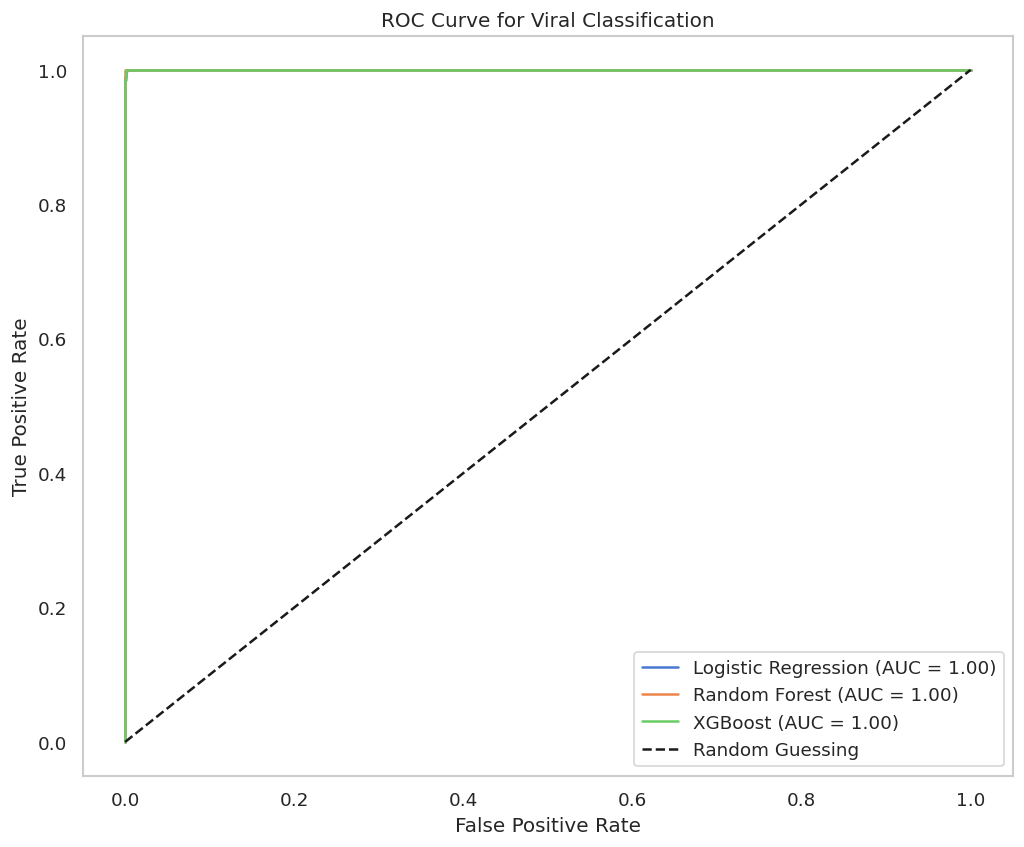


--- Model Comparison ---


,accuracy,precision_viral,recall_viral,f1_viral,roc_auc
Logistic Regression,0.9914,0.9208,1.0000,0.9588,1.0
Random Forest,1.0000,0.9997,1.0000,0.9999,1.0
XGBoost,0.9987,0.9891,0.9976,0.9933,1.0


In [37]:
import joblib # Import joblib for saving models
import os # Import os for path operations
from sklearn.impute import SimpleImputer # Import SimpleImputer for handling NaNs

# Redefine the preprocessor to include imputation for numerical features
# (numerical_cols and categorical_cols are assumed to be available from a previous cell)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum())
}

results = {}

# Define a directory in Google Drive to save models
MODEL_SAVE_DIR = '/content/drive/MyDrive/Colab_Models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True) # Ensure the directory exists

plt.figure(figsize=(10, 8))
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])

    print(f'\nTraining {name}...')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'accuracy': report['accuracy'],
        'precision_viral': report['1']['precision'],
        'recall_viral': report['1']['recall'],
        'f1_viral': report['1']['f1-score'],
        'roc_auc': roc_auc
    }

    print(f'--- {name} Results ---')
    print(classification_report(y_test, y_pred))
    print(f'ROC AUC: {roc_auc:.4f}')

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # Save the trained model pipeline
    model_filename = os.path.join(MODEL_SAVE_DIR, f"{name.lower().replace(' ', '_')}_pipeline.joblib")
    joblib.dump(pipeline, model_filename)
    print(f"Saved {name} model to {model_filename}")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Viral Classification')
plt.legend()
plt.grid()
plt.show()

# Display summary of results
print('\n--- Model Comparison ---')
results_df = pd.DataFrame(results).T
display(results_df.round(4))

# NLP

TF-IDF

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizers
tfidf_vectorizer_title = TfidfVectorizer(max_features=5000)  # Limiting features for manageability
tfidf_vectorizer_desc = TfidfVectorizer(max_features=10000) # Limiting features for manageability

# Fill any NaN values with empty strings before TF-IDF vectorization
df_cleaned['title_clean'] = df_cleaned['title_clean'].fillna('')
df_cleaned['description_clean'] = df_cleaned['description_clean'].fillna('')

# Fit and transform 'title_clean'
title_tfidf = tfidf_vectorizer_title.fit_transform(df_cleaned['title_clean'])
print(f'Shape of TF-IDF matrix for titles: {title_tfidf.shape}')

# Fit and transform 'description_clean'
desc_tfidf = tfidf_vectorizer_desc.fit_transform(df_cleaned['description_clean'])
print(f'Shape of TF-IDF matrix for descriptions: {desc_tfidf.shape}')

print('\nTF-IDF vectorization complete for title_clean and description_clean.')

Shape of TF-IDF matrix for titles: (186652, 5000)
Shape of TF-IDF matrix for descriptions: (186652, 10000)

TF-IDF vectorization complete for title_clean and description_clean.


In [41]:
print('--- TF-IDF Results for Titles ---')
print(f'Type of title_tfidf: {type(title_tfidf)}')
print(f'Shape of title_tfidf: {title_tfidf.shape}')
print(f'Number of non-zero elements in title_tfidf: {title_tfidf.nnz}')
print(f'Sparsity of title_tfidf: {(1 - title_tfidf.nnz / (title_tfidf.shape[0] * title_tfidf.shape[1])) * 100:.2f}%')
print(f'Top 10 title features: {tfidf_vectorizer_title.get_feature_names_out()[:10].tolist()}')

print('\n--- TF-IDF Results for Descriptions ---')
print(f'Type of desc_tfidf: {type(desc_tfidf)}')
print(f'Shape of desc_tfidf: {desc_tfidf.shape}')
print(f'Number of non-zero elements in desc_tfidf: {desc_tfidf.nnz}')
print(f'Sparsity of desc_tfidf: {(1 - desc_tfidf.nnz / (desc_tfidf.shape[0] * desc_tfidf.shape[1])) * 100:.2f}%')
print(f'Top 10 description features: {tfidf_vectorizer_desc.get_feature_names_out()[:10].tolist()}')

--- TF-IDF Results for Titles ---
Type of title_tfidf: <class 'scipy.sparse._csr.csr_matrix'>
Shape of title_tfidf: (186652, 5000)
Number of non-zero elements in title_tfidf: 1157356
Sparsity of title_tfidf: 99.88%
Top 10 title features: ['00', '000', '01', '02', '03', '04', '05', '06', '07', '08']

--- TF-IDF Results for Descriptions ---
Type of desc_tfidf: <class 'scipy.sparse._csr.csr_matrix'>
Shape of desc_tfidf: (186652, 10000)
Number of non-zero elements in desc_tfidf: 3127826
Sparsity of desc_tfidf: 99.83%
Top 10 description features: ['00', '000', '0088', '00pm', '01', '02', '03', '04', '05', '06']


In [43]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Flatten, Concatenate, GlobalAveragePooling1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import joblib
import os

# 1. Prepare Text Data (Embeddings)
MAX_WORDS = 10000
MAX_LEN = 50

# Ensure title_clean is string type to avoid 'float' lower() error
titles_train = X_train['title_clean'].astype(str).fillna('')
titles_test = X_test['title_clean'].astype(str).fillna('')

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df_cleaned['title_clean'].astype(str))

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(titles_train), maxlen=MAX_LEN)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(titles_test), maxlen=MAX_LEN)

# 2. Prepare Numerical/Categorical Data
# We use the preprocessor from previous cells to scale metadata
X_train_meta = preprocessor.fit_transform(X_train)
X_test_meta = preprocessor.transform(X_test)

# 3. Build DNN Model
# Text Input Branch
text_input = Input(shape=(MAX_LEN,), name='text_input')
embedding = Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN)(text_input)
global_pool = GlobalAveragePooling1D()(embedding)

# Metadata Input Branch
meta_input = Input(shape=(X_train_meta.shape[1],), name='meta_input')

# Merge
merged = Concatenate()([global_pool, meta_input])
dense1 = Dense(64, activation='relu')(merged)
dropout1 = Dropout(0.2)(dense1)
dense2 = Dense(32, activation='relu')(dropout1)
output = Dense(1, activation='sigmoid')(dense2)

dnn_model = Model(inputs=[text_input, meta_input], outputs=output)
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# 4. Train Model
print('Training DNN...')
history = dnn_model.fit(
    [X_train_seq, X_train_meta], y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# 5. Evaluate
print('\n--- DNN Evaluation ---')
loss, acc, auc = dnn_model.evaluate([X_test_seq, X_test_meta], y_test, verbose=0)
print(f'Test Accuracy: {acc:.4f}')
print(f'Test AUC: {auc:.4f}')

# 6. Save Model and Tokenizer
MODEL_SAVE_DIR = '/content/drive/MyDrive/Colab_Models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

dnn_model.save(os.path.join(MODEL_SAVE_DIR, 'viral_prediction_dnn.h5'))
joblib.dump(tokenizer, os.path.join(MODEL_SAVE_DIR, 'title_tokenizer.joblib'))

print(f'\nModel and tokenizer saved to {MODEL_SAVE_DIR}')

Training DNN...
Epoch 1/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9638 - auc: 0.9768 - loss: 0.1008 - val_accuracy: 0.9829 - val_auc: 0.9982 - val_loss: 0.0387
Epoch 2/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9887 - auc: 0.9984 - loss: 0.0286 - val_accuracy: 0.9932 - val_auc: 0.9998 - val_loss: 0.0175
Epoch 3/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9934 - auc: 0.9993 - loss: 0.0159 - val_accuracy: 0.9938 - val_auc: 0.9999 - val_loss: 0.0132
Epoch 4/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9957 - auc: 0.9996 - loss: 0.0111 - val_accuracy: 0.9964 - val_auc: 0.9999 - val_loss: 0.0089
Epoch 5/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9968 - auc: 0.9998 - loss: 0.0087 - val_accuracy: 0.9966 - val_auc: 0.9999 - val_loss: 0.0084
Epoch 6/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9972 - auc: 0.9999 - loss: 0.0066 - val_accuracy: 0.9945 - val_auc: 0.9994 - val_loss: 0.0133
Epoch 7/50
934/934 ━━━━

Test Accuracy: 0.9960
Test AUC: 0.9955

Model and tokenizer saved to /content/drive/MyDrive/Colab_Models


1167/1167 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
--- DNN Classification Report ---
              precision    recall  f1-score   support

   Non-Viral       1.00      1.00      1.00     33598
       Viral       0.99      0.97      0.98      3733

    accuracy                           1.00     37331
   macro avg       0.99      0.98      0.99     37331
weighted avg       1.00      1.00      1.00     37331



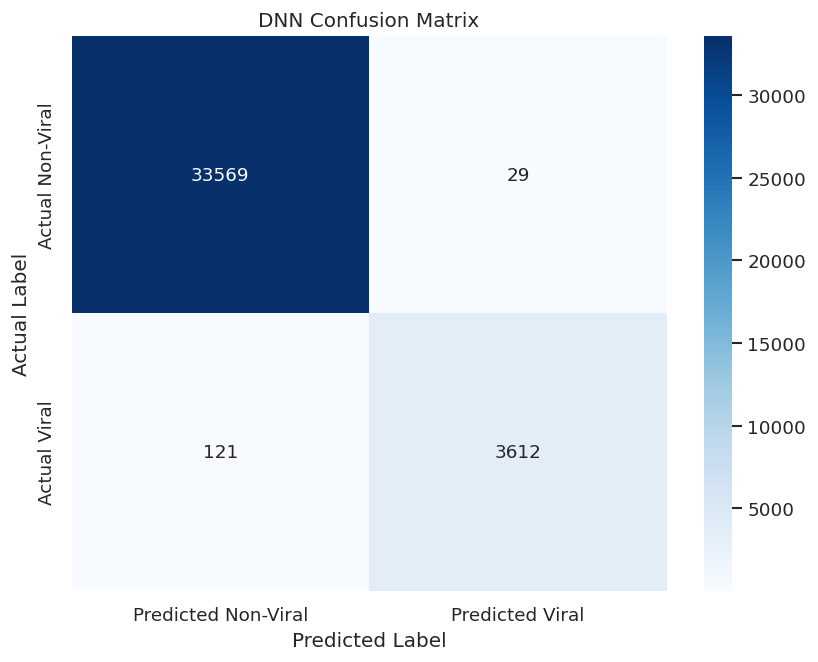

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Get predictions
y_pred_proba = dnn_model.predict([X_test_seq, X_test_meta])
y_pred = (y_pred_proba > 0.5).astype(int)

# 2. Print Classification Report
print('--- DNN Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Non-Viral', 'Viral']))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Viral', 'Predicted Viral'],
            yticklabels=['Actual Non-Viral', 'Actual Viral'])
plt.title('DNN Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()